### v1 Linear AE
 - simple model to check simplest possible approach its strenghts and bottlenecks and set baseline for the future models to beat
 - shallow quick model trained on mse loss
 - latent space dimension 16

 Outputs: 
 
    - the model yet able to perform is only able to learn one representation as a result of its low complexity
    - the models solution is very simple it learns one good representation in  the dataset and maps any input x to the representation
        - the score is computed as MSE(in, out) so the odd shapes score high but the model is unable to locate any sophisticated anomalies
        - not only that the idea in the AEs is to give us somewhat close representation of what the point could look like which is not possible to achieve here due to only output 1 representation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
from anomaly_detection.utils.plotting_styles import apply_global_style

In [3]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [5]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

In [6]:
import torch.nn as nn

# first model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(96, 64),  
            nn.ReLU(),

            nn.Linear(64, 32),  
            nn.ReLU(),
            
            nn.Linear(32, 16),  
            nn.Sigmoid(),
            )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            
            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, 96),
            nn.Sigmoid()
            )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [7]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [8]:
batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ae_lin = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=ae_lin.parameters(), lr=0.0005)

In [9]:
from anomaly_detection.utils.autoencoders import train_ae

ae_lin.train()
train_losses, val_losses, ae_lin = train_ae(n_epochs=250, 
                                            dataloader=train_loader, 
                                            model=ae_lin, 
                                            val_loader=test_loader, 
                                            optimizer=optimizer, 
                                            criterion=criterion, 
                                            save_checkpoints=True, 
                                            saving_after_epoch=20,
                                            model_name="lin_ae",
                                            input_dim=96,
                                            latent_dim=16,)

[Checkpoint created] saved weights in epoch: 24
[Checkpoint created] saved weights in epoch: 28
[Checkpoint created] saved weights in epoch: 29
[Checkpoint created] saved weights in epoch: 37
[Checkpoint created] saved weights in epoch: 38
[Checkpoint created] saved weights in epoch: 39
[Checkpoint created] saved weights in epoch: 40
[Checkpoint created] saved weights in epoch: 41
[Checkpoint created] saved weights in epoch: 42
[Checkpoint created] saved weights in epoch: 43
[Checkpoint created] saved weights in epoch: 44
[Checkpoint created] saved weights in epoch: 45
[Checkpoint created] saved weights in epoch: 67
[Checkpoint created] saved weights in epoch: 76
[Checkpoint created] saved weights in epoch: 77


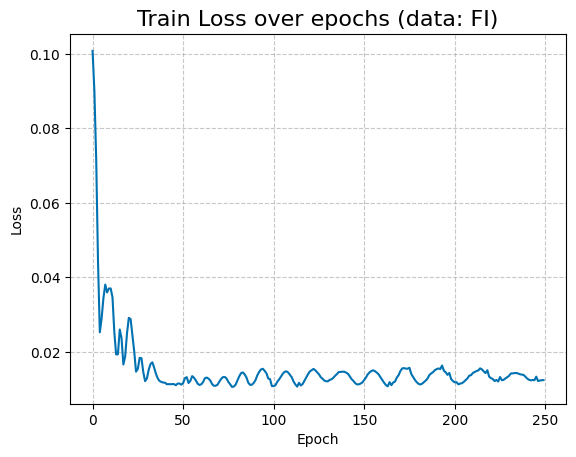

In [10]:
apply_global_style()
plt.title("Train Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(train_losses)), train_losses)
plt.show()

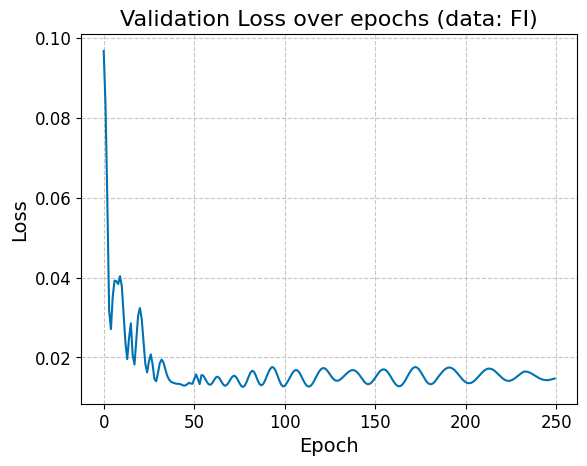

In [11]:
apply_global_style()
plt.title("Validation Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(val_losses)), val_losses)
plt.show()

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


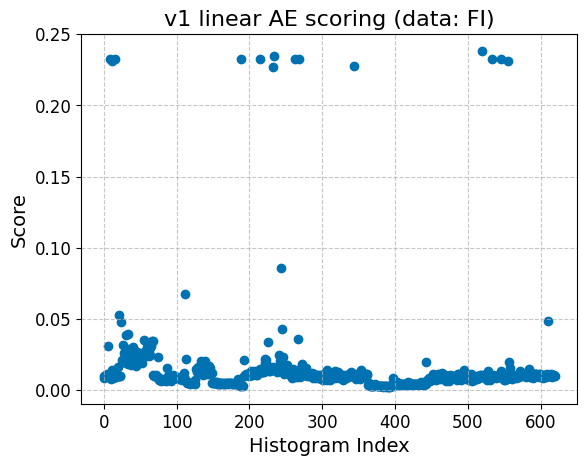

In [12]:
from anomaly_detection.utils.autoencoders import eval_and_plot_score
apply_global_style()
plt.title("v1 linear AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")

full_dataset = HistDataset(full_dataset)
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

scores = []

with torch.no_grad():
    ae_lin.eval()
    for pt in full_dataset:
        pred = ae_lin(pt.reshape(1, 1, 96))
        loss = criterion(pred, pt).detach()
        scores.append(loss.numpy())
plt.scatter(range(len(scores)), scores)
plt.show()

In [13]:
outliers = np.where(np.array(scores) > 0.2)
print(len(outliers[0]))
print(outliers[0].tolist())

14
[8, 11, 15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546, 555]


In [14]:
for idx, pt in enumerate(outliers[0].tolist()):
    if dataset[pt].any() == np.zeros(96).any():
        print(pt)

8
15
188
214
263
268
533
546


In [15]:
preds = list()

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = ae_lin(data).numpy()
         
        for p in preds:
            if pred.all() == p.all():
                break
        else:
            preds.append(pred)
len(preds)

1

tensor(0.0111)


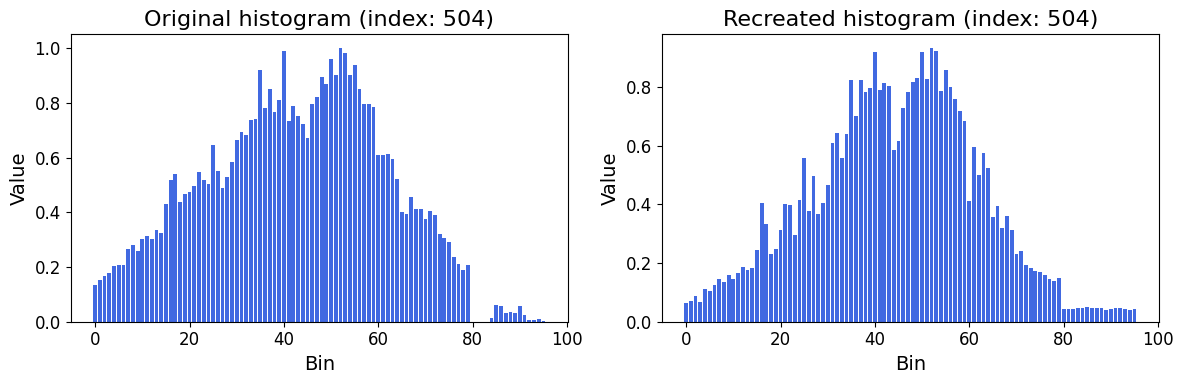

In [16]:
idx = 504

ae_lin.eval()
pred = ae_lin(full_dataset[idx]).detach()

criterion = nn.MSELoss()
loss = criterion(pred, full_dataset[idx])
pred = pred.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), full_dataset[idx].squeeze(), zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Value")

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Value")
print(loss)


plt.tight_layout()
plt.show()

In [17]:
idx = 20
pt = full_dataset[idx]
ae_lin.eval()
embedding = ae_lin.encoder(full_dataset[idx]).detach()
print(embedding.squeeze().numpy())

[1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 0.]


In [18]:
enc_preds = list()

with torch.no_grad():
    ae_lin.eval()
    for idx, data in enumerate(full_dataset):
        embed = ae_lin.encoder(data).numpy()
         
        for p in enc_preds:
            if embed.all() == p.all():
                break
        else:
            enc_preds.append(pred)
len(enc_preds)

620

## Let's see scores of random histograms

In [19]:
from anomaly_detection.config.paths import CHECKPOINT_DIR

save_model = False

if save_model:
    torch.save({
        "model_state_dict": ae_lin.state_dict(),
        "config": {
            "input_dim": 96,
            "latent_dim": 16,
        }
    }, f"{CHECKPOINT_DIR}/lin_autoenc_v1.pth")